### Import Libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt


### Data Loading

In [2]:
before_data = pd.read_csv("data/snapshot_1.csv")
print(f"Shape of before_data {before_data.shape}")
print(f"\nColumns in before_data {before_data.columns}")
print(f"\nData summary\n")
print(before_data.info())

Shape of before_data (75, 5)

Columns in before_data Index(['sku', 'name', 'quantity', 'location', 'last_counted'], dtype='object')

Data summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   sku           75 non-null     object
 1   name          75 non-null     object
 2   quantity      75 non-null     int64 
 3   location      75 non-null     object
 4   last_counted  75 non-null     object
dtypes: int64(1), object(4)
memory usage: 3.1+ KB
None


In [3]:
display(before_data.sample(5))

,sku,name,quantity,location,last_counted
4,SKU-005,Connector Cable 6ft,500,Warehouse C,2024-01-08
55,SKU-056,Keyboard Cleaner Gel,180,Warehouse C,2024-01-08
33,SKU-034,Power Strip,250,Warehouse A,2024-01-08
40,SKU-041,Precision Screwdriver Set,100,Warehouse B,2024-01-08
35,SKU-036,Cable Ties 500pk,400,Warehouse C,2024-01-08


In [4]:
after_data = pd.read_csv("data/snapshot_2.csv")
print(f"Shape of after_data {after_data.shape}")
print(f"\nColumns in after_data {after_data.columns}")
print(f"\nData summary\n")
print(after_data.info())

Shape of after_data (79, 5)

Columns in after_data Index(['sku', 'product_name', 'qty', 'warehouse', 'updated_at'], dtype='object')

Data summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           79 non-null     object 
 1   product_name  79 non-null     object 
 2   qty           79 non-null     float64
 3   warehouse     79 non-null     object 
 4   updated_at    79 non-null     object 
dtypes: float64(1), object(4)
memory usage: 3.2+ KB
None


In [5]:
after_data.head()

,sku,product_name,qty,warehouse,updated_at
0,SKU-001,Widget A,145.0,Warehouse A,2024-01-15
1,SKU-002,Widget B,70.0,Warehouse A,2024-01-15
2,SKU-003,Gadget Pro,185.0,Warehouse B,2024-01-15
3,SKU-004,Gadget Lite,48.0,Warehouse A,2024-01-15
4,SKU005,Connector Cable 6ft,480.0,Warehouse C,2024-01-15


In [6]:
display(after_data.sample(10))

,sku,product_name,qty,warehouse,updated_at
28,SKU-031,Surge Protector 12-Outlet,112.0,Warehouse A,2024-01-15
65,SKU-067,Tripod Small,52.0,Warehouse B,2024-01-15
39,SKU-042,Wire Stripper,70.0,Warehouse B,2024-01-15
76,SKU-078,Capture Card,12.0,Warehouse A,2024-01-15
31,SKU-034,Power Strip,240.0,Warehouse A,2024-01-15
2,SKU-003,Gadget Pro,185.0,Warehouse B,2024-01-15
51,SKU-054,Microfiber Cloth 10pk,285.0,Warehouse C,2024-01-15
10,SKU-011,LED Panel 12x12,115.0,Warehouse A,2024-01-15
78,SKU-080,Thunderbolt Cable,30.0,Warehouse A,2024-01-15
41,SKU-044,Multimeter Basic,35.0,Warehouse A,2024-01-15


In [7]:
print(before_data.describe())

          quantity
count    75.000000
mean    257.200000
std     334.512796
min      15.000000
25%      52.500000
50%     150.000000
75%     300.000000
max    2000.000000


In [8]:
print(after_data.describe())

               qty
count    79.000000
mean    232.379747
std     311.725730
min      -5.000000
25%      43.500000
50%     115.000000
75%     285.000000
max    1850.000000


In [9]:
print(f"Minus value in quanitiy column which is concerning!")

Minus value in quanitiy column which is concerning!


### Exploratory Data Analysis

##### Is sku column is formatted consistently? 

Length consistency, case consistency, whitespace & hidden characters, pattern consistency, cross-snapshot consistency, uniquess --> all these will silently break merge() and cause problems.

##### Uniqueness

In [10]:
print(f"Shape of before_data {before_data.shape}")
print(f"Number of unique sku in the before_data : {before_data['sku'].nunique()}")
#------------------------------------------------
print(f"\nShape of after_data {after_data.shape}")
print(f"Number of unique sku in the after_data : {after_data['sku'].nunique()}")

Shape of before_data (75, 5)
Number of unique sku in the before_data : 75

Shape of after_data (79, 5)
Number of unique sku in the after_data : 78


##### Length consistency

In [11]:
# See the distribution of SKU lengths
print(before_data['sku'].str.len().value_counts())

# Find SKUs that don't match the most common length
common_len_1 = before_data['sku'].str.len().mode()[0]
print(f"Common length : {common_len_1}")
print(f"Number of sku that don't match most of common length \n")
print(len(before_data[before_data['sku'].str.len() != common_len_1]))
display(before_data[before_data['sku'].str.len() != common_len_1].head())

sku
7    75
Name: count, dtype: int64
Common length : 7
Number of sku that don't match most of common length 

0


,sku,name,quantity,location,last_counted


In [12]:
# See the distribution of SKU lengths
print(after_data['sku'].str.len().value_counts())

# Find SKUs that don't match the most common length
common_len_2 = after_data['sku'].str.len().mode()[0]
print(f"Common length : {common_len_2}")
print(f"Number of sku that don't match most of common length \n")
print(len(after_data[after_data['sku'].str.len() != common_len_2]))
display(after_data[after_data['sku'].str.len() != common_len_2].head())

sku
7    77
6     2
Name: count, dtype: int64
Common length : 7
Number of sku that don't match most of common length 

2


,sku,product_name,qty,warehouse,updated_at
4,SKU005,Connector Cable 6ft,480.0,Warehouse C,2024-01-15
17,SKU018,Ethernet Cable Cat5,750.0,Warehouse C,2024-01-15


##### Case consistency

In [13]:
# Case consistency --> SKU vs SkU
all_upper_1 = (before_data['sku'] == before_data['sku'].str.upper()).all()
all_lower_1 = (before_data['sku'] == before_data['sku'].str.lower()).all()

if all_upper_1:
    print("All SKUs are uppercase in before_data")
elif all_lower_1:
    print("All SKUs are lowercase in before_data")
else:
    print("Mixed case formatting detected in before_data")
    is_upper_1 = before_data['sku'] == before_data['sku'].str.upper()
    print(f"Uppercase: {is_upper_1.sum()}, Not uppercase: {(~is_upper_1).sum()}")

#----------------------------------------------------------
print("\n")

all_upper_2 = (after_data['sku'] == after_data['sku'].str.upper()).all()
all_lower_2 = (after_data['sku'] == after_data['sku'].str.lower()).all()

if all_upper_2:
    print("All SKUs are uppercase in after_data")
elif all_lower_2:
    print("All SKUs are lowercase in after_data")
else:
    print("Mixed case formatting detected in after_data")
    is_upper_2 = after_data['sku'] == after_data['sku'].str.upper()
    print(f"Uppercase: {is_upper_2.sum()}, Not uppercase: {(~is_upper_2).sum()}")


All SKUs are uppercase in before_data


Mixed case formatting detected in after_data
Uppercase: 78, Not uppercase: 1


##### Whitespaces

In [14]:
# Count how many SKUs change after stripping
has_whitespace_1 = before_data['sku'] != before_data['sku'].str.strip()
print(f"White spaces in before_data {has_whitespace_1.sum()}")  

# See the actual offenders
before_data[has_whitespace_1]['sku'].apply(repr)  # repr() makes spaces visible

#-------------------------------------------
has_whitespace_2 = after_data['sku'] != after_data['sku'].str.strip()
print(f"White spaces in after_data {has_whitespace_1.sum()}")  

after_data[has_whitespace_2]['sku'].apply(repr)  # repr() makes spaces visible

White spaces in before_data 0
White spaces in after_data 0


Series([], Name: sku, dtype: object)

##### Hidden characters

In [15]:
# hidden characters 
# Check if any SKU contains non-printable characters
has_hidden_1 = before_data['sku'].str.contains(r'[^\x20-\x7E]', regex=True)
print(f"Hidden characters in before_data : { has_hidden_1.sum()}")
before_data[has_hidden_1]['sku'].apply(repr)

#--------------------------------------------
has_hidden_2 = after_data['sku'].str.contains(r'[^\x20-\x7E]', regex=True)
print(f"Hidden characters in after_data : { has_hidden_2.sum()}")
after_data[has_hidden_2]['sku'].apply(repr)


Hidden characters in before_data : 0
Hidden characters in after_data : 0


Series([], Name: sku, dtype: object)

##### Null values check

In [16]:
print(f"Null values in before_data : \n{before_data.isnull().sum()}")
print(f"Null values in after_data : \n{after_data.isnull().sum()}")

print(f"\nAt what percentages (before_data): \
    \n{(before_data.isnull().sum() / len(before_data) * 100).round(2)}")
print(f"At what percentages (after_data): \
    \n{(after_data.isnull().sum() / len(after_data) * 100).round(2)}")

Null values in before_data : 
sku             0
name            0
quantity        0
location        0
last_counted    0
dtype: int64
Null values in after_data : 
sku             0
product_name    0
qty             0
warehouse       0
updated_at      0
dtype: int64

At what percentages (before_data):     
sku             0.0
name            0.0
quantity        0.0
location        0.0
last_counted    0.0
dtype: float64
At what percentages (after_data):     
sku             0.0
product_name    0.0
qty             0.0
warehouse       0.0
updated_at      0.0
dtype: float64


##### Disguised nulls

In [17]:
print(f"In before_data: \n")
for col in before_data.columns:
    suspicious = before_data[col].isin(['', 'N/A', 'None', 'null', '-', 'nan', 'NaN'])
    if suspicious.any():
        print(f"{col}: {suspicious.sum()} disguised nulls")

In before_data: 



In [18]:
print(f"In after_data: \n")
for col in after_data.columns:
    suspicious = after_data[col].isin(['', 'N/A', 'None', 'null', '-', 'nan', 'NaN'])
    if suspicious.any():
        print(f"{col}: {suspicious.sum()} disguised nulls")

In after_data: 



##### Duplication checks

In [19]:
# row duplicates 
print(f"Row duplications in before_data : {before_data.duplicated().sum()}")
print(f"Row duplications in after_data : {after_data.duplicated().sum()}")

Row duplications in before_data : 0
Row duplications in after_data : 0


In [20]:
# key duplicates 
print(f"Key duplications in before_data : {before_data.duplicated(subset=['sku']).sum()}")
print(f"Key duplications in after_data : {after_data.duplicated(subset=['sku']).sum()}")

Key duplications in before_data : 0
Key duplications in after_data : 1


In [21]:
# show duplicates
after_data[after_data.duplicated(subset=['sku'],keep=False)]

,sku,product_name,qty,warehouse,updated_at
42,SKU-045,Multimeter Professional,23.0,Warehouse A,2024-01-15
52,SKU-045,Multimeter Pro,-5.0,Warehouse B,2024-01-15


In [22]:
before_data[before_data['sku']=='SKU-045']

,sku,name,quantity,location,last_counted
44,SKU-045,Multimeter Pro,25,Warehouse A,2024-01-08


##### Datetime data

In [23]:
converted_1 = pd.to_datetime(before_data['last_counted'], errors='coerce')

print(f"Min in before data: {converted_1.min()}")
print(f"Max in before data: {converted_1.max()}")

failed_1 = before_data[converted_1.isna() & before_data['last_counted'].notna()]
print(f"Unparseable dates: {len(failed_1)}")
print(failed_1['last_counted'].unique())

display(failed_1.head())

Min in before data: 2024-01-08 00:00:00
Max in before data: 2024-01-08 00:00:00
Unparseable dates: 0
[]


,sku,name,quantity,location,last_counted


In [24]:
converted_2 = pd.to_datetime(after_data['updated_at'], errors='coerce')

print(f"Min in after data: {converted_2.min()}")
print(f"Max in after data: {converted_2.max()}")

failed_2 = after_data[converted_2.isna() & after_data['updated_at'].notna()]
print(f"Unparseable dates: {len(failed_2)}")
print(failed_2['updated_at'].unique())

display(failed_2.head())

Min in after data: 2024-01-15 00:00:00
Max in after data: 2024-01-15 00:00:00
Unparseable dates: 1
['01/15/2024']


,sku,product_name,qty,warehouse,updated_at
32,SKU-035,Cable Ties 100pk,1420.0,Warehouse C,01/15/2024


##### SKU vs Product name combination mismatch

In [25]:

merged = before_data.merge(after_data, left_on='sku', right_on='sku', how='inner')


mismatched = merged[
    merged['name'].str.strip().str.lower() != merged['product_name'].str.strip().str.lower()
]

print(f"Mismatches: {len(mismatched)}")
print(mismatched[['sku', 'name', 'product_name']])

Mismatches: 1
        sku            name             product_name
39  SKU-045  Multimeter Pro  Multimeter Professional


##### Basic stats

In [26]:
print("=== Snapshot 1 ===")
print(before_data.describe())
print("\n=== Snapshot 2 ===")
print(after_data.describe())

=== Snapshot 1 ===
          quantity
count    75.000000
mean    257.200000
std     334.512796
min      15.000000
25%      52.500000
50%     150.000000
75%     300.000000
max    2000.000000

=== Snapshot 2 ===
               qty
count    79.000000
mean    232.379747
std     311.725730
min      -5.000000
25%      43.500000
50%     115.000000
75%     285.000000
max    1850.000000


In [27]:
before_data['location'].value_counts()

location
Warehouse A    33
Warehouse B    23
Warehouse C    19
Name: count, dtype: int64

In [28]:
after_data['warehouse'].value_counts()

warehouse
Warehouse A    38
Warehouse B    22
Warehouse C    19
Name: count, dtype: int64

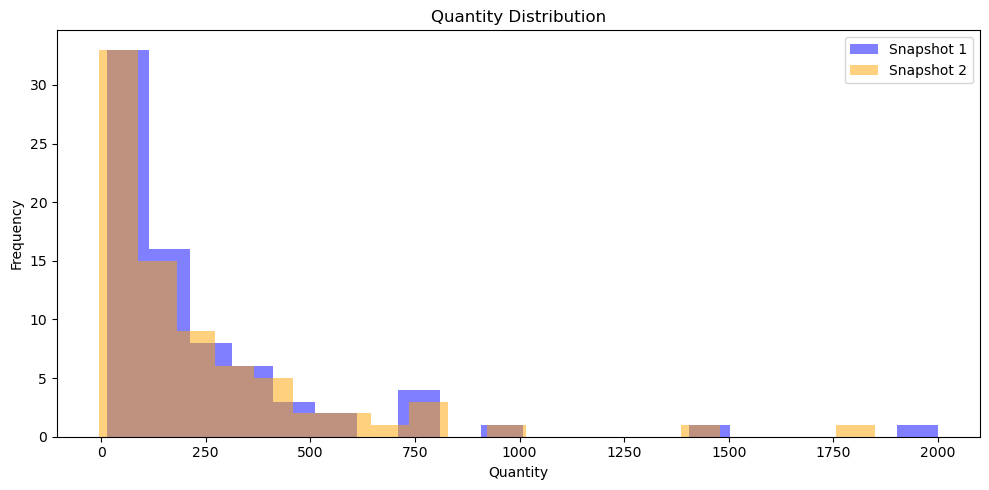

In [29]:
plt.figure(figsize=(10, 5))
plt.hist(before_data['quantity'], bins=20, alpha=0.5, label='Snapshot 1', color='blue')
plt.hist(pd.to_numeric(after_data['qty'], errors='coerce'), bins=20, alpha=0.5, label='Snapshot 2', color='orange')
plt.title('Quantity Distribution')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
after_data[after_data['qty']<=0]

,sku,product_name,qty,warehouse,updated_at
52,SKU-045,Multimeter Pro,-5.0,Warehouse B,2024-01-15
